In [50]:
import IPython.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

plt.rcParams['figure.figsize'] = [10, 5]

In [51]:
#store start and end times in array
df = pd.read_csv("20230422_171301.Detections.selections.txt", sep="\t") #tabs are used to seperate columns

pad = 0.1
start_t = df["Begin Time (s)"].values - pad
end_t = df["End Time (s)"].values + pad

In [52]:
#Clip wanted audio segment from the original audio file
fn = "20230422_171301.WAV"
f_s, x = wavfile.read(fn)

call_no = 1
start_sample = int(start_t[call_no] * f_s)
end_sample = int(end_t[call_no] * f_s)

audio_segment = x[start_sample:end_sample]

IPython.display.Audio(audio_segment, rate=f_s)

(0.0, 4000.0)

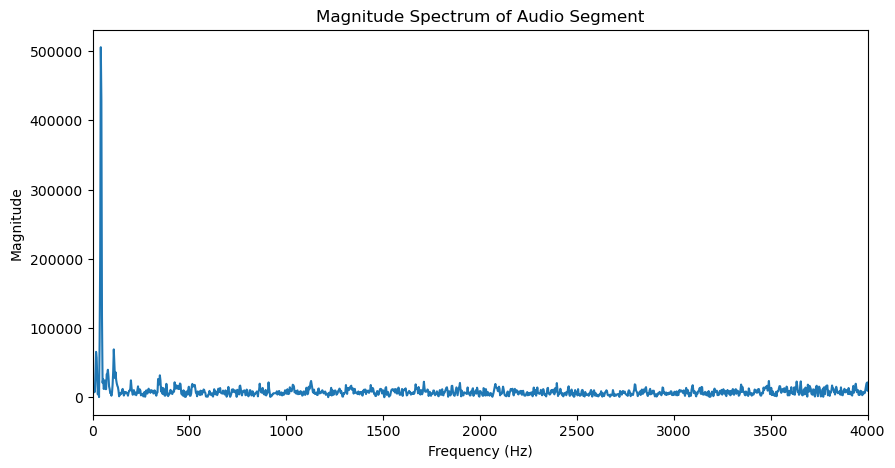

In [53]:
N = len(audio_segment)
w = np.hamming(N)
spectrum = np.fft.fft(audio_segment * w)

plt.plot(np.linspace(0, f_s*(N-1)/N, N), np.abs(spectrum));
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum of Audio Segment")
plt.xlim(0, f_s/2)

In [54]:
framelength = 1024
noverlap = int(framelength * 0.5)
window = "hamming"

In [55]:
f, t, fft_frames = signal.stft(audio_segment, f_s, nperseg=framelength, noverlap=noverlap, window=window)

(0.0, 4000.0)

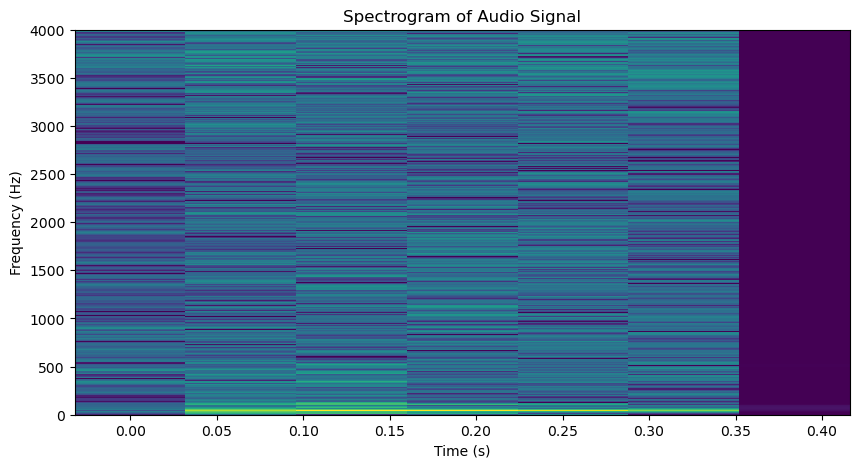

In [56]:
plt.pcolormesh(t, f, np.log(np.abs(fft_frames + 1e-16)), vmin = 0, vmax = np.max(np.log(np.abs(fft_frames + 1e-16))));
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Audio Signal")
plt.ylim(0, f_s/2)